In [1]:
from data_utils import *
from import_pkgs import *

In [4]:
aircraft_obs = pd.read_csv(dc8_obs_path).replace([-999999, -888888, -777777], np.nan)
Q_SCALE = (28.97 / 18.015) * 1e6   # kg/kg → ppmv 

lat_obs      = aircraft_obs['Latitude_BENNETT'].to_numpy('float64')
lon_obs      = aircraft_obs['Longitude_BENNETT'].to_numpy('float64')
pressure_obs = aircraft_obs['Static_Pressure_BENNETT'].to_numpy('float64')    # hPa
altitude_m   = aircraft_obs['Pressure_Altitude_BENNETT'].to_numpy('float64') * 0.3048  # ft→m

obs_vals = {
    'T'   : aircraft_obs['Static_Air_Temp_BENNETT'].to_numpy('float64'),  # °C
    'Q'   : aircraft_obs['H2O_DLH_DISKIN'].to_numpy('float64') / Q_SCALE  * 1e3, # ppmv -> kg/kg
    'CO'  : aircraft_obs['CO_DACOM_DISKIN'].to_numpy('float64'),  # ppbv                  
    'NO2' : aircraft_obs['NO2_pptv'].to_numpy('float64')/1000,    # pptv -> ppbv
    'O3'  : aircraft_obs['O3_ppbv'].to_numpy('float64')          # ppbv
}

all_nan = np.all(~np.isfinite(np.stack([
    aircraft_obs['OA_PM1.5_AMS'].to_numpy('float64'),
    aircraft_obs['Sulfate_PM1.5_AMS'].to_numpy('float64'),
    aircraft_obs['Nitrate_PM1.5_AMS'].to_numpy('float64'),
    aircraft_obs['Ammonium_PM1.5_AMS'].to_numpy('float64'),
    aircraft_obs['NR_Chloride_PM1.5_AMS'].to_numpy('float64'),
    aircraft_obs['BC_mass'].to_numpy('float64'),
], axis=1)), axis=1)


ctrl_aircraft = xr.open_dataset(ctrl_aircraft_file)
test_aircraft = xr.open_dataset(test_aircraft_file)
output_lev    = ctrl_aircraft.lev.values   

track_file = xr.open_dataset(dc8_track_path)
lat_fl = track_file['lat_fl'].values   
lon_fl = track_file['lon_fl'].values   

# match each obs point to nearest model ncol
tree = cKDTree(np.column_stack([lat_fl, lon_fl]))
_, ncol_match = tree.query(np.column_stack([lat_obs, lon_obs])) 

# match obs pressure to nearest model pressure level
lev_match = np.abs(pressure_obs[:, None] - output_lev[None, :]).argmin(axis=1) 

def extract_matched(da, ncol_idx, lev_idx):
    return da.values[ncol_idx, lev_idx]

ctrl_vals = {
    'T'   : extract_matched(ctrl_aircraft['T'],    ncol_match, lev_match) - 273.15,
    'Q'   : extract_matched(ctrl_aircraft['Q'],    ncol_match, lev_match) * 1e3,
    'CO'  : extract_matched(ctrl_aircraft['CO'],   ncol_match, lev_match) * 1e9,
    'NO2' : extract_matched(ctrl_aircraft['NO2'],  ncol_match, lev_match) * 1e9,
    'O3'  : extract_matched(ctrl_aircraft['O3'],   ncol_match, lev_match) * 1e9
}
test_vals = {
    'T'   : extract_matched(test_aircraft['T'],    ncol_match, lev_match) - 273.15,
    'Q'   : extract_matched(test_aircraft['Q'],    ncol_match, lev_match) * 1e3,
    'CO'  : extract_matched(test_aircraft['CO'],   ncol_match, lev_match) * 1e9,
    'NO2' : extract_matched(test_aircraft['NO2'],  ncol_match, lev_match) * 1e9,
    'O3'  : extract_matched(test_aircraft['O3'],   ncol_match, lev_match) * 1e9
}

# Observations
q_kgkg_obs = obs_vals['Q'] / Q_SCALE
e_obs      = q_kgkg_obs * pressure_obs / 0.622
e_s_obs    = 6.112 * np.exp(17.67 * obs_vals['T'] / (obs_vals['T'] + 243.5))
obs_vals['RH'] = (e_obs / e_s_obs) * 100

# CTRL
q_kgkg_ctrl = ctrl_vals['Q'] / Q_SCALE
e_ctrl       = q_kgkg_ctrl * pressure_obs / 0.622
e_s_ctrl     = 6.112 * np.exp(17.67 * ctrl_vals['T'] / (ctrl_vals['T'] + 243.5))
ctrl_vals['RH'] = (e_ctrl / e_s_ctrl) * 100

# TEST
q_kgkg_test = test_vals['Q'] / Q_SCALE
e_test       = q_kgkg_test * pressure_obs / 0.622
e_s_test     = 6.112 * np.exp(17.67 * test_vals['T'] / (test_vals['T'] + 243.5))
test_vals['RH'] = (e_test / e_s_test) * 100


# keep only obs below both CTRL and TEST PBLH
ctrl_pblh_at_obs = ctrl_aircraft['PBLH'].values[ncol_match]   
test_pblh_at_obs = test_aircraft['PBLH'].values[ncol_match]   
below_pbl = (altitude_m < ctrl_pblh_at_obs) & (altitude_m < test_pblh_at_obs)

obs_pts = gpd.GeoDataFrame(
    geometry=[Point(lo, la) for lo, la in zip(lon_obs, lat_obs)],
    crs='EPSG:4326')

city_masks = {
    'Bangkok'   : np.array(obs_pts.geometry.within(bak_shapefile)) & below_pbl,
    'Seoul'     : np.array(obs_pts.geometry.within(seo_shapefile)) & below_pbl,
    'Manila'    : np.array(obs_pts.geometry.within(mal_shapefile)) & below_pbl,
    'Kaohsiung' : np.array(obs_pts.geometry.within(kao_shapefile)) & below_pbl,
}

city_masks_nopblh = {
    'Bangkok'   : np.array(obs_pts.geometry.within(bak_shapefile)),
    'Seoul'     : np.array(obs_pts.geometry.within(seo_shapefile)),
    'Manila'    : np.array(obs_pts.geometry.within(mal_shapefile)),
    'Kaohsiung' : np.array(obs_pts.geometry.within(kao_shapefile)) ,
}

VARIABLES = ['T', 'Q', 'O3', 'NO2', 'CO']
CITIES    = ['Bangkok', 'Manila', 'Seoul', 'Kaohsiung']
UNIT_LABELS = {
    'T'   : '°C',
    'Q'  : 'kg/kg',
    'O3'  : 'ppb',
    'NO2' : 'ppb',
    'CO'  : 'ppb',
}
VAR_LABELS = {
    'T'   : 'T',
    'Q'   : 'Q',
    'WSpeed': 'WSpeed', 
    'WDir': 'WDir',
    'O3'  : r'O$_3$',
    'NO2' : r'NO$_2$',
    'CO'  : 'CO',
}

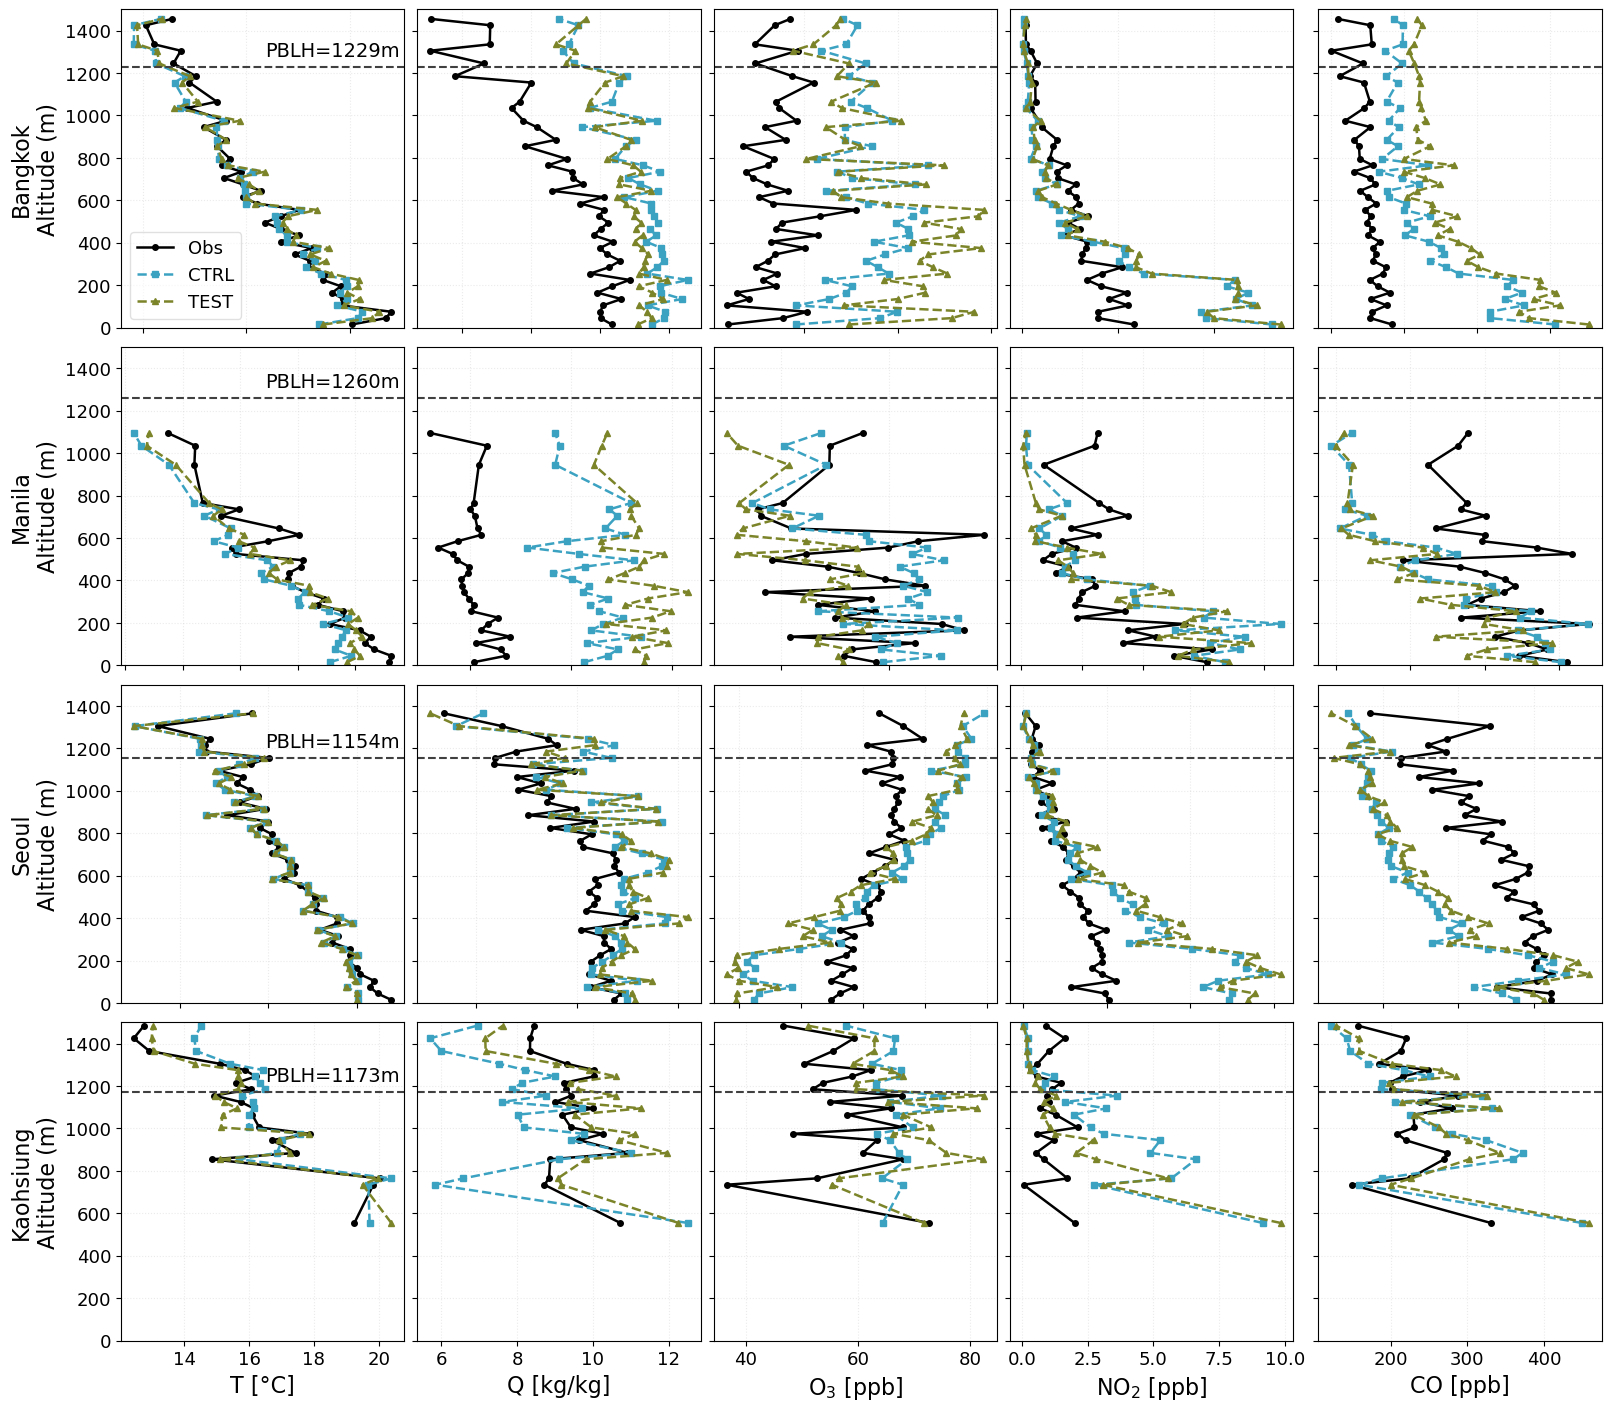

In [10]:
N_BINS = 50
ALT_MAX = 1500 
n_cities = 4
n_vars = 5

city_pblh_mean = {}
for city, shp_mask in city_masks_nopblh.items():
    alt_in_range = shp_mask & (altitude_m <= ALT_MAX)
    pblh_vals = 0.5 * (ctrl_pblh_at_obs[alt_in_range] + test_pblh_at_obs[alt_in_range])
    city_pblh_mean[city] = np.nanmean(pblh_vals) if alt_in_range.sum() > 0 else np.nan
    
def plot_city_row(axes_row, city, mask, show_xlabel=False, show_legend=False):
    # restrict to 0–1500 m
    alt_mask = mask & (altitude_m <= ALT_MAX)
    alt      = altitude_m[alt_mask]
    n_pts    = int(alt_mask.sum())

    edges       = np.linspace(0, ALT_MAX, N_BINS + 1)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx     = np.clip(np.digitize(alt, edges) - 1, 0, N_BINS - 1)

    ci = CITIES.index(city)

    for ax, var in zip(axes_row, VARIABLES):
        obs_v  = obs_vals[var][alt_mask]
        ctrl_v = ctrl_vals[var][alt_mask]
        test_v = test_vals[var][alt_mask]

        obs_bin  = np.full(N_BINS, np.nan)
        ctrl_bin = np.full(N_BINS, np.nan)
        test_bin = np.full(N_BINS, np.nan)

        for b in range(N_BINS):
            idx = bin_idx == b
            if idx.sum() >= 3:
                obs_bin[b]  = np.nanmean(obs_v[idx])
                ctrl_bin[b] = np.nanmean(ctrl_v[idx])
                test_bin[b] = np.nanmean(test_v[idx])

        valid = np.isfinite(obs_bin) & np.isfinite(ctrl_bin) & np.isfinite(test_bin)

        ax.plot(obs_bin[valid],  bin_centers[valid],
                color='black',   lw=1.8, marker='o', ms=4, label='Obs')
        ax.plot(ctrl_bin[valid], bin_centers[valid],
                color='#3ca2c2', lw=1.8, marker='s', ms=4,
                linestyle='--',  label='CTRL')
        ax.plot(test_bin[valid], bin_centers[valid],
                color='#7c8429', lw=1.8, marker='^', ms=4,
                linestyle='--',  label='TEST')

        pblh_mean = city_pblh_mean[city]
        if np.isfinite(pblh_mean) and pblh_mean <= ALT_MAX:
            ax.axhline(pblh_mean, color='#404040', lw=1.5,
                       linestyle='--')
            if var == VARIABLES[0]:
                ax.text(0.51, pblh_mean / ALT_MAX + 0.02,
                        f'PBLH={pblh_mean:.0f}m',
                        transform=ax.transAxes,
                        color='black', fontsize=14, va='bottom', ha='left')

        ax.set_ylim(0, ALT_MAX)
        ax.grid(True, alpha=0.25, linestyle=':')
        ax.tick_params(labelsize=13)

        if show_xlabel:
            ax.set_xlabel(f'{VAR_LABELS[var]} [{UNIT_LABELS[var]}]', fontsize=16)
        else:
            ax.tick_params(labelbottom=False)

    axes_row[0].set_ylabel(f'{city}\nAltitude (m)', fontsize=16)

    if show_legend:
        axes_row[0].legend(fontsize=13, loc='best', framealpha=0.6)

fig, axes = plt.subplots(
    n_cities, n_vars,
    figsize=(3.2 * n_vars, 3.5 * n_cities),
    sharey='row',
    constrained_layout=True,
)

for ri, city in enumerate(CITIES):
    plot_city_row(
        axes[ri],
        city        = city,
        mask        = city_masks_nopblh[city],
        show_xlabel = (ri == n_cities - 1),
        show_legend = (ri == 0),
    )

plt.show()